In [ ]:
pip install torch_geometric

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 64.4/64.4 kB 1.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 9.7 MB/s eta 0:00:00


In [ ]:
# 1. دانلود مستقیم فایل در پوشه content با استفاده از شناسه فایل
!gdown --id "1B9A10ODg8ArIKfOI18LxsrXfa8KcAGqP"

# 2. از حالت فشرده خارج کردن فایل در همان پوشه content
!unzip "my_code.zip" -d "/content/"

/usr/local/lib/python3.13/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1B9A10ODg8ArIKfOI18LxsrXfa8KcAGqP
From (redirected): https://drive.google.com/uc?id=1B9A10ODg8ArIKfOI18LxsrXfa8KcAGqP&confirm=t&uuid=609ef0dd-adf3-41de-a1b7-c91943804b83
To: /content/my_code.zip
100% 50.5M/50.5M [00:00<00:00, 81.7MB/s]
Archive:  my_code.zip
   creating: /content/utils/
  inflating: /content/utils/metrics.py  
  inflating: /content/utils/seed.py  
  inflating: /content/utils/__init__.py  
   creating: /content/utils/__pycache__/
  inflating: /content/utils/__pycache__/metrics.cpython-310.pyc  
  inflating: /content/utils/__pycache__/seed.cpython-310.pyc  
  inflating: /content/utils/__pycache__/__init__.cpython-310.pyc  
  inflating: /content/config.py      
  inflating: /content/main.ipynb 

# MNCL
Final integrated implementation: data pipeline, three graph views, losses, training, checkpoint/resume, and CTR evaluation.

> Before a long run, execute `python verify_environment.py --dataset last-fm` and `python smoke_check.py` from the project root.


In [ ]:
import matplotlib.pyplot as plt
import torch
from config import MNCLConfig
from datasets import build_graphs, load_dataset, split_ratings
from losses import MNCLLoss
from models import MNCL
from training import evaluate_checkpoint, load_checkpoint, move_graphs_to_device, resolve_device, train_epochs
from utils import set_seed


In [78]:
config = MNCLConfig(dataset="movie")
config.l2_lambda = 1e-6
config.K = 3
config.beta = 0
set_seed(config.seed)
device = resolve_device(config.device)
print("device:", device)


device: cuda


In [79]:
print("dataset:", config.dataset)
print("embedding_dim:", config.embedding_dim)
print("tau:", config.tau)
print("best checkpoint:", config.best_checkpoint_path())
print("latest checkpoint:", config.latest_checkpoint_path())


dataset: movie
embedding_dim: 64
tau: 0.6
best checkpoint: checkpoints/movie_best.pt
latest checkpoint: checkpoints/movie_latest.pt


In [80]:
data = load_dataset(config)
split = split_ratings(
    data.ratings,
    test_ratio=config.test_ratio,
    seed=config.seed,
)
graphs = build_graphs(data, split)
graphs = move_graphs_to_device(graphs, device)


In [81]:
print(data.info)
print("train:", split.train_ratings.shape)
print("test:", split.test_ratings.shape)
print("user-item edges:", graphs.user_item.edge_index.shape)
print("kg edges:", graphs.kg.edge_index.shape)


DatasetInfo(M=6036, N=2445, K=179566, L=12)
train: (603120, 3)
test: (150652, 3)
user-item edges: torch.Size([2, 603120])
kg edges: torch.Size([2, 1241995])


## Model initialization
Run this cell once for a new training session. Re-running only the train cell below does not reinitialize the model.

In [82]:
model = MNCL(data.info, config).to(device)
loss_fn = MNCLLoss(
    alpha=config.alpha,
    l2_lambda=config.l2_lambda,
    temperature=config.tau,
    omega=config.omega,
    bpr_reduction=config.bpr_reduction,
).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=config.lr)

total_train_loss = []
total_test_loss = []


## Resume checkpoint (optional)
Run this cell only when you want to continue a saved run. Use `latest` to continue the most recent state, or change the path to `best` to continue from the lowest test loss.


In [ ]:
resume_path = config.latest_checkpoint_path()
# resume_path = config.best_checkpoint_path()

if resume_path.exists():
    checkpoint_state = load_checkpoint(
        path=resume_path,
        model=model,
        optimizer=optimizer,
        device=device,
        restore_rng=True,
    )
    total_train_loss = list(checkpoint_state.train_history)
    total_test_loss = list(checkpoint_state.test_history)
    print("resumed:", checkpoint_state.path)
    print("completed epochs:", checkpoint_state.epoch)
    print("best test loss:", checkpoint_state.best_test_loss)
else:
    print("checkpoint not found:", resume_path)


## Train block
You can run this cell repeatedly. The existing model and optimizer are reused.

In [ ]:
for param_group in optimizer.param_groups:
    param_group["lr"] = 0.0001

In [83]:
train_loss, test_loss = train_epochs(
    model=model,
    optimizer=optimizer,
    loss_fn=loss_fn,
    graphs=graphs,
    train_ratings=split.train_ratings,
    test_ratings=split.test_ratings,
    num_epochs=5,
    batch_size=config.batch_size,
    device=device,
    seed=config.seed,
    start_epoch=len(total_train_loss),
    num_workers=config.num_workers,
    pin_memory=config.pin_memory,
    best_checkpoint_path=config.best_checkpoint_path(),
    latest_checkpoint_path=config.latest_checkpoint_path(),
    total_train_loss=total_train_loss,
    total_test_loss=total_test_loss,
    best_test_loss=min(total_test_loss, default=float("inf")),
    config=config,
)

total_train_loss.extend(train_loss)
total_test_loss.extend(test_loss)

print("best checkpoint:", config.best_checkpoint_path())
print("latest checkpoint:", config.latest_checkpoint_path())


MNCL training:   0%|          | 0/5 [00:00<?, ?it/s]

Epoch 1 train:   0%|          | 0/74 [00:00<?, ?it/s]

Epoch 2 train:   0%|          | 0/74 [00:00<?, ?it/s]

KeyboardInterrupt: 

## Loss curves

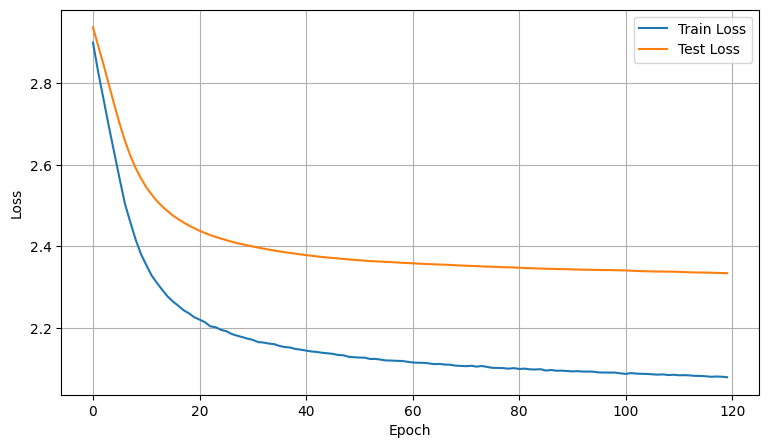

In [73]:
start = 0
plt.figure(figsize=(9, 5))
plt.plot(total_train_loss[start:], label="Train Loss")
plt.plot(total_test_loss[start:], label="Test Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)
textstr = '\n'.join((
    f'Learning Rate: {config.lr:.4f}',
    f'beta: {config.beta:.4f}',
    f'L2 norm: {config.l2_lambda:.4f}'
))
plt.show()


## CTR evaluation
Load the best checkpoint into a separate model so the current training state is not changed.


In [76]:
evaluation_model = MNCL(data.info, config).to(device)

evaluation_result = evaluate_checkpoint(
    checkpoint_path=config.best_checkpoint_path(),
    model=evaluation_model,
    graphs=graphs,
    ratings=split.test_ratings,
    batch_size=config.batch_size,
    device=device,
    threshold=config.f1_threshold,
)

metrics = evaluation_result.metrics
print("checkpoint:", evaluation_result.checkpoint.path)
print("epoch:", evaluation_result.checkpoint.epoch)
print(f"AUC: {metrics.auc:.4f}")
print(f"F1: {metrics.f1:.4f}")
print(f"Precision: {metrics.precision:.4f}")
print(f"Recall: {metrics.recall:.4f}")


CTR evaluation:   0%|          | 0/3 [00:00<?, ?it/s]

checkpoint: checkpoints/last-fm_best.pt
epoch: 138
AUC: 0.8707
F1: 0.7583
Precision: 0.6617
Recall: 0.8879


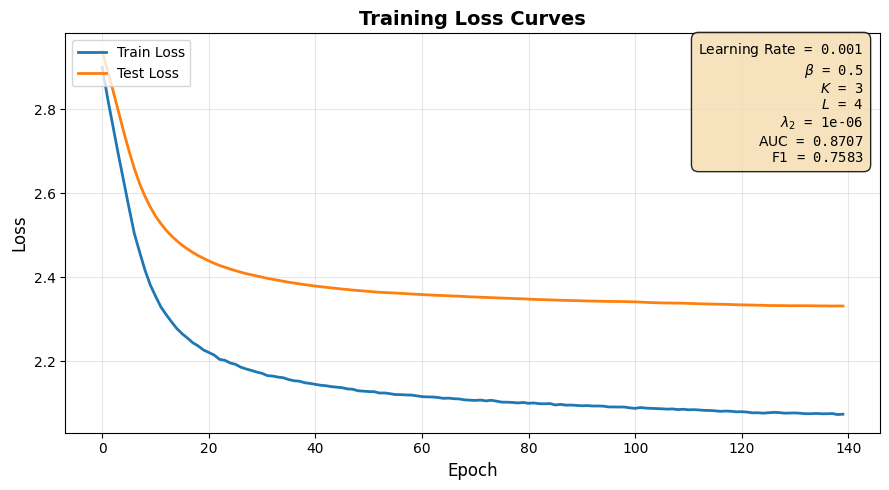

In [77]:
plt.figure(figsize=(9, 5))
plt.plot(total_train_loss, label="Train Loss", linewidth=2)
plt.plot(total_test_loss, label="Test Loss", linewidth=2)
plt.xlabel("Epoch", fontsize=12)
plt.ylabel("Loss", fontsize=12)
plt.legend(loc='upper left')
plt.grid(True, alpha=0.3)

# ایجاد باکس اطلاعات با فرمت زیبا (سمت راست بالا)
info_text = (
    f"$\\mathrm{{Learning\\ Rate}}$ = {config.lr}\n"
    f"$\\beta$ = {config.beta}\n"
    f"$K$ = {config.K}\n"
    f"$L$ = {config.L}\n"
    f"$\\lambda_2$ = {config.l2_lambda}\n"
    f"$\\mathrm{{AUC}}$ = {metrics.auc:.4f}\n"
    f"$\\mathrm{{F1}}$ = {metrics.f1:.4f}"
)

props = dict(boxstyle='round,pad=0.5', facecolor='wheat', alpha=0.85)
plt.text(0.98, 0.98, info_text,
         transform=plt.gca().transAxes,
         fontsize=10,
         verticalalignment='top',
         horizontalalignment='right',  # راست‌چین کردن متن
         bbox=props,
         family='monospace')

plt.title('Training Loss Curves', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()